# Questioning DARE - is Abstinence Only Education Truly Effective?
Nadia Synyavska

Repository Link - [nsynyavska23.github.io](https://github.com/nsynyavska23/nsynyavska23.github.io)

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import re
pd.set_option('display.max_rows', None, 'display.max_columns', None)

# Project Goals:
I would like to investigate the effectiveness of DARE, a prevention program that brings in law enforcement officers to teach an abstinence only curriculum around drugs, alcohol, and peer pressure. DARE was introduced in 1983, and gained popularity in school districts across the country by the 1990s. Mainly I would like to determine what the best metric of the effectiveness of the program is (potentially considering self reported attitudes towards drug use, rates of drug use, and spending on the program), and whether or not the rates of teenage drug use actually decreased during the years in which the program was the most active across the country. For now, I am going to be using the [SAMHSA (Substance Abuse and Mental Health Services Administration) NSDUH (National Survey on Drug Use and Health) Detailed Tables](https://www.samhsa.gov/data/data-we-collect/nsduh-national-survey-drug-use-and-health/datafiles).

# Collaboration Plan
I will be working alone on this project. I will set up a GitHub repository to store and update my code, and I will be organizing notebooks based on milestone in my personal Google Drive.

# Table 1:
I will be using data from a national survey of drug use and health, conducted by the a branch of the US department of health that focuses on substance abuse and mental health. The survey has been issued yearly since 1971, and gives national estimates of substance use in Americans age 12 and up.

The unit of observation in the dataset is a year, with each row representing a national annual average for a given age group. Variables include past-month use rates for marijuana, alcohol, and cigarettes, past-year illicit drug use, and the mean age of first marijuana use. For this milestone, I'll be focusing on the row that shows ages 12-17 (this age group would be the most likely to be targeted by DARE).

Questions I am hoping can be answered from this data and lead to more relevant information include, "Did drug use rates change in the 12-17 age group during DARE's peak years?" "Does choice of substance (marijuana, alcohol, cigarettes, etc) change our conclusions?" and "Did DARE actually delay the age at which teenagers tried drugs for the first time?"

Some challenges I had with the ETL:


*   A lot of DARE's peak years pre 2002 (1980s-90s) aren't well documented
*   Missing values are indicated with a '*' symbol and not 'NaN'
*   SAMHSA says that 2020-2021 surveys were conducted online and not in person due to COVID regulations, which could cause issues because of a lack of consistency with data collection methodology in those years (I'm not sure yet how to deal with this issue in my analysis)
*   I could not directly download the dataframe







In [3]:
# NSDUH portal blocks direct download
# Instead get the dataframe from published NSDUH figures
# I have taken all values from SAMHSA's annual Detailed Tables (Sections 1 and 2)
# Download file manually from the SAMHSA data portal
# Swap in pd.read_csv('nsduh_trends.csv')

data = {
    'year': [
        2002, 2003, 2004, 2005, 2006, 2007,
        2008, 2009, 2010, 2011, 2012, 2013,
        2014, 2015, 2016, 2017, 2018, 2019
    ],
    # Past-month marijuana use rate, ages 12-17 (%) - NSDUH Table 1.1B
    'marijuana_past_month_pct': [
        8.2, 7.9, 7.6, 6.8, 6.7, 6.7,
        6.7, 7.3, 7.4, 7.9, 7.2, 7.1,
        7.4, 7.0, 6.5, 6.5, 6.7, 6.6
    ],
    # Past-month alcohol use rate, ages 12-17 (%) - NSDUH Table 2.1B
    'alcohol_past_month_pct': [
        17.6, 17.7, 17.6, 16.5, 16.6, 15.9,
        14.6, 14.7, 13.6, 13.0, 12.9, 11.6,
        11.5, 10.9,  9.8,  9.5,  9.0,  8.2
    ],
    # Past-month cigarette use rate, ages 12-17 (%) - NSDUH Table 2.7B
    'cigarette_past_month_pct': [
        13.0, 12.2, 11.9, 10.8, 10.4,  9.8,
         9.1,  8.9,  8.3,  7.8,  6.6,  5.6,
         4.9,  4.2,  3.4,  2.9,  2.5,  2.3
    ],
    # Past-year any illicit drug use rate, ages 12-17 (%) - NSDUH Table 1.1B
    'any_illicit_past_year_pct': [
        24.5, 23.0, 21.5, 19.8, 19.8, 19.7,
        19.6, 20.7, 21.3, 22.7, 22.5, 22.2,
        21.7, 20.0, 18.6, 18.5, 18.5, 18.2
    ],
    # Mean age of first marijuana use among past-year initiates - NSDUH Table 1.22A
    'mean_age_first_marijuana': [
        17.0, 17.0, 17.1, 17.1, 17.2, 17.1,
        17.2, 17.0, 17.1, 17.1, 17.0, 16.9,
        17.0, 17.1, 17.0, 17.1, 17.1, 17.2
    ],
}

nsduh_df = pd.DataFrame(data)
nsduh_df.head()

,year,marijuana_past_month_pct,alcohol_past_month_pct,cigarette_past_month_pct,any_illicit_past_year_pct,mean_age_first_marijuana
0,2002,8.2,17.6,13.0,24.5,17.0
1,2003,7.9,17.7,12.2,23.0,17.0
2,2004,7.6,17.6,11.9,21.5,17.1
3,2005,6.8,16.5,10.8,19.8,17.1
4,2006,6.7,16.6,10.4,19.8,17.2


Now, we have to replace unreliable (I'm now wondering what exactly qualifies as unreliable) subgroup estimates. The marking is indicated with symbols and not an empty cell, which means pandas won't treat that row as missing data.

In [4]:
def replace_missing(entry):
    entry = str(entry).strip()
    if re.search(r'^[\*a\-]+$', entry):  # matches *, a, --, --- (NSDUH markers for unreliable estimates)
        return np.nan
    return entry

In [5]:
value_columns = [c for c in nsduh_df.columns if c != 'year']
for column in value_columns:
    nsduh_df[column] = nsduh_df[column].apply(replace_missing)
print(len(nsduh_df)) # we should have 18 rows for 18 years (2002-2019)

18


In [6]:
nsduh_df.dtypes

,0
year,int64
marijuana_past_month_pct,object
alcohol_past_month_pct,object
cigarette_past_month_pct,object
any_illicit_past_year_pct,object
mean_age_first_marijuana,object


Columns are still typed as objects, so we need to convert them to floats.

In [8]:
for column in value_columns:
    nsduh_df[column] = nsduh_df[column].astype(float)
nsduh_df.dtypes # now float type

,0
year,int64
marijuana_past_month_pct,float64
alcohol_past_month_pct,float64
cigarette_past_month_pct,float64
any_illicit_past_year_pct,float64
mean_age_first_marijuana,float64


In [10]:
nsduh_df  # dataframe after tidying

,year,marijuana_past_month_pct,alcohol_past_month_pct,cigarette_past_month_pct,any_illicit_past_year_pct,mean_age_first_marijuana
0,2002,8.2,17.6,13.0,24.5,17.0
1,2003,7.9,17.7,12.2,23.0,17.0
2,2004,7.6,17.6,11.9,21.5,17.1
3,2005,6.8,16.5,10.8,19.8,17.1
4,2006,6.7,16.6,10.4,19.8,17.2
5,2007,6.7,15.9,9.8,19.7,17.1
6,2008,6.7,14.6,9.1,19.6,17.2
7,2009,7.3,14.7,8.9,20.7,17.0
8,2010,7.4,13.6,8.3,21.3,17.1
9,2011,7.9,13.0,7.8,22.7,17.1


# Interesting Statistics

In [13]:
#1: How much did marijuana use actually change over the 18 years examined?
mj_2002 = nsduh_df.loc[nsduh_df['year'] == 2002, 'marijuana_past_month_pct'].values[0]
mj_2019 = nsduh_df.loc[nsduh_df['year'] == 2019, 'marijuana_past_month_pct'].values[0]
print(f"Past-month marijuana use (ages 12-17): {mj_2002}% in 2002 to {mj_2019}% in 2019")
print(f"Change: {mj_2019 - mj_2002:+.1f} percentage points over 17 years")
print(f"Is this a significant enough decrease in useage to attribute it to DARE's effectiveness?")

Past-month marijuana use (ages 12-17): 8.2% in 2002 to 6.6% in 2019
Change: -1.6 percentage points over 17 years
Is this a significant enough decrease in useage to attribute it to DARE's effectiveness?


In [15]:
#2: The age of first time marijuana use barely changed over the years.
age_mean = nsduh_df['mean_age_first_marijuana'].mean()
age_std  = nsduh_df['mean_age_first_marijuana'].std()
print(f"Mean age of first marijuana use among initiates: {age_mean:.2f} years (std: {age_std:.2f})")
print(f"DARE aimed to delay drug experimentation in teenagers.")
print(f"Based off of the mean and standard deviation over the years, the age of first use of marijuana is basically unchanged.")

Mean age of first marijuana use among initiates: 17.07 years (std: 0.08)
DARE aimed to delay drug experimentation in teenagers.
Based off of the mean and standard deviation over the years, the age of first use of marijuana is basically unchanged.


In [17]:
#3: Alcohol use remained fairly high over the years.
alc_min_idx  = nsduh_df['alcohol_past_month_pct'].idxmin()
alc_min_year = nsduh_df.loc[alc_min_idx, 'year']
alc_min_val  = nsduh_df.loc[alc_min_idx, 'alcohol_past_month_pct']
alc_mean     = nsduh_df['alcohol_past_month_pct'].mean()
print(f"Youth alcohol use averaged {alc_mean:.1f}% between 2002-2019.")
print(f"The lowest rate of {alc_min_val}% in {alc_min_year}% still seems high.")
print(f"Does this raise an issue with abstinence only education about substances?")

Youth alcohol use averaged 13.4% between 2002-2019.
The lowest rate of 8.2% in 2019% still seems high.
Does this raise an issue with abstinence only education about substances?


In [19]:
#4: Cigarette use decreased the most out of any substance.
cig_2002 = nsduh_df.loc[nsduh_df['year'] == 2002, 'cigarette_past_month_pct'].values[0]
cig_2019 = nsduh_df.loc[nsduh_df['year'] == 2019, 'cigarette_past_month_pct'].values[0]
cig_rel_drop = ((cig_2019 - cig_2002) / cig_2002) * 100
print(f"Past-month cigarette use (ages 12-17): {cig_2002}% in 2002 to {cig_2019}% in 2019")
print(f"Relative decline: {cig_rel_drop:.1f}%")
print(f"Does this have more to do with DARE or with the increased regulation of tobacco?")

Past-month cigarette use (ages 12-17): 13.0% in 2002 to 2.3% in 2019
Relative decline: -82.3%
Does this have more to do with DARE or with the increased regulation of tobacco?


# Visualization
This chart shows past-month use rates for marijuana, alcohol, and cigarettes among youth aged 12–17 from 2002 to 2019.

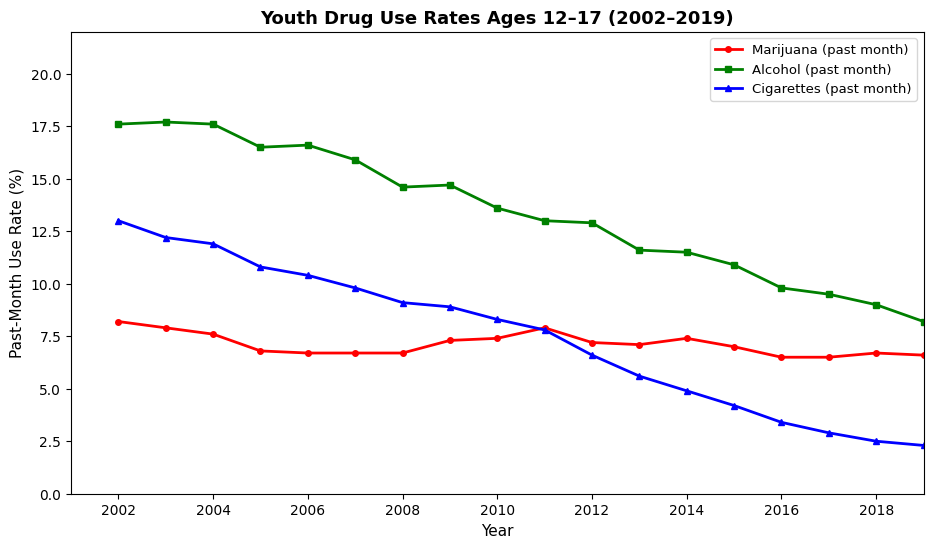

In [32]:
# Create a figure and set of axes for plot
fig, ax = plt.subplots(figsize=(11, 6))

# Marijuana usage past month
ax.plot(nsduh_df['year'], nsduh_df['marijuana_past_month_pct'],
        color = 'red', linewidth = 2, marker = 'o', markersize = 4,
        label = 'Marijuana (past month)')

# Alcohol usage past month
ax.plot(nsduh_df['year'], nsduh_df['alcohol_past_month_pct'],
        color = 'green', linewidth = 2, marker = 's', markersize = 4,
        label = 'Alcohol (past month)')

# Cigarettes usage past month
ax.plot(nsduh_df['year'], nsduh_df['cigarette_past_month_pct'],
        color = 'blue', linewidth = 2, marker = '^', markersize = 4,
        label = 'Cigarettes (past month)')

ax.set_title(
    'Youth Drug Use Rates Ages 12–17 (2002–2019)',
    fontsize = 13, fontweight = 'bold'
)
ax.set_xlabel('Year', fontsize = 11)
ax.set_ylabel('Past-Month Use Rate (%)', fontsize = 11)
ax.set_xlim(2001, 2019)
ax.set_ylim(0, 22)
ax.legend(loc='upper right', fontsize=9.5)

plt.show()

# Closing Thoughts and Final Goals:
I'm still not sure which metric to use to gauge the success of DARE. We see trends like cigarette useage hugely dropping, while marijuana useage remaining fairly constant, and alcohol useage remaining relatively high. How can we know what can be attributed to DARE and what externalities need to be examined?

Going forward, I'm hoping to find a way to accurately factor in years pre 2002. In addition, I want to control potential externalities, such as economic and demographic factors, missing data due to participants not being honest on the surveys, and other policy restrictions or programs affecting substance use.